In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import random
import jax
print("JAX devices:", jax.devices())
import jax.numpy as jnp
from jax import jit
from tqdm import tqdm
from matplotlib.patches import Polygon

plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Computer Modern']
plt.rcParams.update({'font.size': 14})
plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)

JAX devices: [CpuDevice(id=0)]


# NESTED SAMPLING INTEGRATION

In [3]:
# =============================================================================
# OUTPUT DIRECTORY FOR PLOTS
# =============================================================================
PLOT_DIR = "plots"
os.makedirs(PLOT_DIR, exist_ok=True)

# ===============================================
# PLATE PARAMETERS
# -----------------------------------------------
n_retractors = 40 # 168
r = 205  # mm, half of 205mm field
n_tiers = 3
n_fibres = n_retractors * n_tiers

# Retractor coordinates & constraints
angles = jnp.linspace(0, 2*jnp.pi, n_retractors, endpoint=False)  # placement of fibres
retractor_x = jnp.asarray(r * jnp.cos(angles))
retractor_y = jnp.asarray(r * jnp.sin(angles))
# fibre_span_allowed = jnp.asarray([r*0.4, r*0.7, r*1.3])  # for tiers 0,1,2 (low-high)
fibre_span_allowed = jnp.asarray([180, 190 , 200]) # for tiers 0,1,2 (low-high)
phi_max = jnp.deg2rad(14)  # max bend angle

# Button vertices in local fibre-target coordinates
# box of 9mm length, 2mm width
button_vertices_local = jnp.array([
    [-1,  6],
    [ 1,  6],
    [ 1, -3],
    [-1, -3],
])

# Minimum possible target separation
min_sep = 2  # mm; min. distance of separation below which buttons overlap

# -----------------------------------------------
# FIELD PARAMETERS
# -----------------------------------------------
n_targets = 1400  # 1400

# ===============================================

def rand_targets(R, n):
    """
    Generate random targets uniform over a disc.
    """
    rng = np.random.default_rng(0)
    p = rng.random(n)
    q = rng.random(n)
    rr = R * np.sqrt(p)
    theta = 2*np.pi*q
    x = rr * np.cos(theta)
    y = rr * np.sin(theta)
    return jnp.asarray(x), jnp.asarray(y)

def fibre_id(retractor_id, tier_id):
    if tier_id < 0 or tier_id >= n_tiers:
        raise ValueError("Invalid tier_id")
    return retractor_id * n_tiers + tier_id

def fibre_rt(fibre_id_):
    r_id = fibre_id_ // n_tiers
    t_id = fibre_id_ % n_tiers
    return r_id, t_id

# -----------------------------------------------
# PHASE 1: Reachability & button footprints
# -----------------------------------------------
@jit
def TF_reach_matrix(px, py):
    fibre_ids = jnp.arange(n_fibres)      # (F,)
    r_ids = fibre_ids // n_tiers          # (F,)
    t_ids = fibre_ids % n_tiers           # (F,)

    rx = retractor_x[r_ids]               # (F,)
    ry = retractor_y[r_ids]               # (F,)
    tier_span = fibre_span_allowed[t_ids] # (F,)

    pos_r = jnp.stack([rx, ry], axis=1)  # (F,2)
    pos_r_norm_inward = -pos_r / jnp.linalg.norm(pos_r, axis=1, keepdims=True)

    vx = px[None, :] - rx[:, None]     # (F, T)
    vy = py[None, :] - ry[:, None]     # (F, T)
    v_len = jnp.sqrt(vx**2 + vy**2) + 1e-12

    ux = vx / v_len
    uy = vy / v_len

    dot = (ux * pos_r_norm_inward[:, 0:1] + uy * pos_r_norm_inward[:, 1:2])
    dot = jnp.clip(dot, -1.0, 1.0)
    ang = jnp.arccos(dot)

    span_allowed = tier_span[:, None]
    allowed = (v_len <= span_allowed) & (ang <= phi_max)
    return allowed

@jit
def all_button_vertices(px, py, allowed):
    F = allowed.shape[0]
    T = allowed.shape[1]

    fibre_ids = jnp.arange(F)
    r_ids = fibre_ids // n_tiers

    rx = retractor_x[r_ids, None]
    ry = retractor_y[r_ids, None]

    tx = px[None, :]
    ty = py[None, :]

    vx = tx - rx
    vy = ty - ry
    phi = jnp.arctan2(vy, vx)
    theta = phi + jnp.pi / 2

    c = jnp.cos(theta)
    s = jnp.sin(theta)

    bx = button_vertices_local[:, 0]
    by = button_vertices_local[:, 1]

    bx_broadcast = bx[None, None, :]
    by_broadcast = by[None, None, :]

    x_rot = c[:, :, None] * bx_broadcast - s[:, :, None] * by_broadcast
    y_rot = s[:, :, None] * bx_broadcast + c[:, :, None] * by_broadcast

    x_vertex = px[None, :, None] + x_rot
    y_vertex = py[None, :, None] + y_rot

    mask = allowed[:, :, None]
    x_vertex = jnp.where(mask, x_vertex, jnp.nan)
    y_vertex = jnp.where(mask, y_vertex, jnp.nan)

    vertices = jnp.stack([x_vertex, y_vertex], axis=-1)  # (F, T, 4, 2)
    return vertices

@jax.jit
def compute_target_bboxes(vertices):
    xmin = jnp.nanmin(vertices[..., 0], axis=(0, 2))
    xmax = jnp.nanmax(vertices[..., 0], axis=(0, 2))
    ymin = jnp.nanmin(vertices[..., 1], axis=(0, 2))
    ymax = jnp.nanmax(vertices[..., 1], axis=(0, 2))
    footprint_valid = jnp.isfinite(xmin)
    return xmin, ymin, xmax, ymax, footprint_valid

@jax.jit
def compute_bbox_overlap(xmin, ymin, xmax, ymax, footprint_valid):
    xmin_i = xmin[:, None];  xmin_j = xmin[None, :]
    xmax_i = xmax[:, None];  xmax_j = xmax[None, :]
    ymin_i = ymin[:, None];  ymin_j = ymin[None, :]
    ymax_i = ymax[:, None];  ymax_j = ymax[None, :]

    overlap = (
        (xmax_i >= xmin_j) &
        (xmax_j >= xmin_i) &
        (ymax_i >= ymin_j) &
        (ymax_j >= ymin_i)
    )

    valid_i = footprint_valid[:, None]
    valid_j = footprint_valid[None, :]
    overlap = overlap & valid_i & valid_j

    T = xmin.shape[0]
    overlap = overlap & (~jnp.eye(T, dtype=bool))

    overlap = jnp.triu(overlap, k=1)
    overlap = overlap | overlap.T
    return overlap

# ----------------------------------------------------------------
# PHASE 2 — pair-level checks independent of fibre assignment
# ----------------------------------------------------------------
@jax.jit
def always_collide(px, py, reachable_Ts, min_sep):
    xi = px[:, None]
    yi = py[:, None]
    dx = xi - xi.T
    dy = yi - yi.T
    d2 = dx**2 + dy**2

    T = px.shape[0]
    d2 = d2 + jnp.eye(T) * jnp.inf

    collide = d2 < (min_sep * min_sep)
    both_reachable = reachable_Ts[:, None] & reachable_Ts[None, :]
    always_c = collide & both_reachable

    always_c = jnp.triu(always_c, k=1)
    always_c = always_c | always_c.T
    always_c = jnp.where(jnp.eye(T, dtype=bool), False, always_c)
    return always_c

def seg_seg_intersect(p, r, q, s, eps=1e-9):
    """
    Input:
        p, r, q, s are (..., 2) arrays representing segments
        p -> p + r   and   q -> q + s

    Output:
        boolean array of shape (...) indicating whether the segments intersect.

    This handles:
      - ordinary crossings
      - endpoint touching
      - parallel but disjoint segments
      - collinear overlapping segments
    """
    def cross(a, b):
        return a[..., 0] * b[..., 1] - a[..., 1] * b[..., 0]

    def dot(a, b):
        return a[..., 0] * b[..., 0] + a[..., 1] * b[..., 1]

    q_p = q - p
    rxs = cross(r, s)
    q_pxr = cross(q_p, r)

    # Parallel and collinear tests
    parallel = jnp.abs(rxs) < eps
    collinear = parallel & (jnp.abs(q_pxr) < eps)

    # -----------------------------
    # 1) Non-parallel case
    # -----------------------------
    rxs_safe = jnp.where(parallel, 1.0, rxs)

    t = cross(q_p, s) / rxs_safe
    u = cross(q_p, r) / rxs_safe

    proper_intersect = (
        (~parallel) &
        (t >= 0.0) & (t <= 1.0) &
        (u >= 0.0) & (u <= 1.0)
    )

    # -----------------------------
    # 2) Collinear case
    # -----------------------------
    rr = dot(r, r)
    ss = dot(s, s)

    # Handle degenerate segments safely
    rr_safe = jnp.where(rr < eps, 1.0, rr)
    ss_safe = jnp.where(ss < eps, 1.0, ss)

    # If both are points
    p_is_point = rr < eps
    q_is_point = ss < eps

    same_point = p_is_point & q_is_point & (jnp.linalg.norm(p - q, axis=-1) < eps)

    # If p-segment is a point, test whether p lies on q-segment
    qp_dot_s = dot(p - q, s)
    point_p_on_q = (
        p_is_point & (~q_is_point) & collinear &
        (qp_dot_s >= -eps) & (qp_dot_s <= ss + eps)
    )

    # If q-segment is a point, test whether q lies on p-segment
    q_p_dot_r = dot(q_p, r)
    point_q_on_p = (
        q_is_point & (~p_is_point) & collinear &
        (q_p_dot_r >= -eps) & (q_p_dot_r <= rr + eps)
    )

    # General collinear overlap: project q and q+s onto p->p+r
    t0 = dot(q_p, r) / rr_safe
    t1 = t0 + dot(s, r) / rr_safe

    tmin = jnp.minimum(t0, t1)
    tmax = jnp.maximum(t0, t1)

    collinear_overlap = (
        collinear &
        (~p_is_point) & (~q_is_point) &
        (tmax >= -eps) & (tmin <= 1.0 + eps)
    )

    return proper_intersect | same_point | point_p_on_q | point_q_on_p | collinear_overlap

@jax.jit
def compute_path_bboxes(px, py, retractor_x, retractor_y, r_id_for_fibre, allowed):
    F, T = allowed.shape
    rx_f = retractor_x[r_id_for_fibre]
    ry_f = retractor_y[r_id_for_fibre]
    rx = rx_f[:, None]
    ry = ry_f[:, None]

    tx = jnp.broadcast_to(px[None, :], (F, T))
    ty = jnp.broadcast_to(py[None, :], (F, T))

    seg_xmin = jnp.minimum(tx, rx)
    seg_xmax = jnp.maximum(tx, rx)
    seg_ymin = jnp.minimum(ty, ry)
    seg_ymax = jnp.maximum(ty, ry)

    big = 1e30
    seg_xmin = jnp.where(allowed, seg_xmin, big)
    seg_ymin = jnp.where(allowed, seg_ymin, big)
    seg_xmax = jnp.where(allowed, seg_xmax, -big)
    seg_ymax = jnp.where(allowed, seg_ymax, -big)

    path_xmin = jnp.min(seg_xmin, axis=0)
    path_ymin = jnp.min(seg_ymin, axis=0)
    path_xmax = jnp.max(seg_xmax, axis=0)
    path_ymax = jnp.max(seg_ymax, axis=0)

    return path_xmin, path_ymin, path_xmax, path_ymax

@jax.jit
def compute_fibre_segments(px, py, retractor_x, retractor_y, r_id_for_fibre, allowed):
    F, T = allowed.shape
    target_pos = jnp.stack([px, py], axis=-1)
    start = jnp.broadcast_to(target_pos[None, :, :], (F, T, 2))

    rx = retractor_x[r_id_for_fibre]
    ry = retractor_y[r_id_for_fibre]
    end = jnp.stack([rx[:, None], ry[:, None]], axis=-1)  # (F,1,2)

    vector = end - start
    mask = allowed[..., None]
    start = jnp.where(mask, start, jnp.nan)
    vector = jnp.where(mask, vector, jnp.nan)
    return start, vector

@jax.jit
def fibre_collision_block_padded(target_vertices, target_fibre_start, target_fibre_dir, target_fibre_mask, t1, t2):
    verts_i = target_vertices[t1]
    verts_j = target_vertices[t2]

    edges_i = jnp.roll(verts_i, -1, axis=1) - verts_i
    edges_j = jnp.roll(verts_j, -1, axis=1) - verts_j

    mask_i = target_fibre_mask[t1]
    mask_j = target_fibre_mask[t2]

    p_bb = verts_i[:, None, :, None, :]
    r_bb = edges_i[:, None, :, None, :]
    q_bb = verts_j[None, :, None, :, :]
    s_bb = edges_j[None, :, None, :, :]

    intersects_bb = seg_seg_intersect(p_bb, r_bb, q_bb, s_bb)
    button_intersect = jnp.any(intersects_bb, axis=(2, 3))

    start_i = target_fibre_start[t1]
    dir_i   = target_fibre_dir[t1]

    p_fb1 = start_i[:, None, None, :]
    r_fb1 = dir_i[:, None, None, :]
    q_fb1 = verts_j[None, :, :, :]
    s_fb1 = edges_j[None, :, :, :]

    intersects_fb1 = seg_seg_intersect(p_fb1, r_fb1, q_fb1, s_fb1)
    f1_on_b2 = jnp.any(intersects_fb1, axis=2)

    start_j = target_fibre_start[t2]
    dir_j   = target_fibre_dir[t2]

    p_fb2 = start_j[None, :, None, :]
    r_fb2 = dir_j[None, :, None, :]
    q_fb2 = verts_i[:, None, :, :]
    s_fb2 = edges_i[:, None, :, :]

    intersects_fb2 = seg_seg_intersect(p_fb2, r_fb2, q_fb2, s_fb2)
    f2_on_b1 = jnp.any(intersects_fb2, axis=2)

    block = button_intersect | f1_on_b2 | f2_on_b1

    valid_i = mask_i[:, None]
    valid_j = mask_j[None, :]
    valid_pair = valid_i & valid_j
    block = block & valid_pair
    return block

@jax.jit
def batch_collision_blocks(target_vertices, target_fibre_start, target_fibre_dir, target_fibre_mask, t1_batch, t2_batch):
    def one_pair(t1, t2):
        return fibre_collision_block_padded(
            target_vertices, target_fibre_start, target_fibre_dir,
            target_fibre_mask, t1, t2
        )
    return jax.vmap(one_pair)(t1_batch, t2_batch)

# ================================================
# COLLISION MATRIX
# ================================================
fibre_ids = jnp.arange(n_fibres)
r_id_for_fibre = fibre_ids // n_tiers
t_id_for_fibre = fibre_ids % n_tiers

px, py = rand_targets(r, n_targets)

allowed = TF_reach_matrix(px, py)
reachable_Ts = jnp.any(allowed, axis=0)

always_collide_mat = always_collide(px, py, reachable_Ts, min_sep)

vertices = all_button_vertices(px, py, allowed)
xmin, ymin, xmax, ymax, footprint_valid = compute_target_bboxes(vertices)

path_xmin, path_ymin, path_xmax, path_ymax = compute_path_bboxes(
    px, py, retractor_x, retractor_y, r_id_for_fibre, allowed
)

pxmin = path_xmin[:, None]
pymin = path_ymin[:, None]
pxmax = path_xmax[:, None]
pymax = path_ymax[:, None]

fxmin = xmin[None, :]
fymin = ymin[None, :]
fxmax = xmax[None, :]
fymax = ymax[None, :]

pathA_hits_footB = (
    (pxmin <= fxmax) &
    (pxmax >= fxmin) &
    (pymin <= fymax) &
    (pymax >= fymin)
)
path_bbox_overlap = pathA_hits_footB | pathA_hits_footB.T
path_bbox_overlap = path_bbox_overlap & (~jnp.eye(path_bbox_overlap.shape[0], dtype=bool))

bbox_overlap = compute_bbox_overlap(xmin, ymin, xmax, ymax, footprint_valid)
needs_fibre_level = (~always_collide_mat) & (bbox_overlap | path_bbox_overlap)

print("Pairs needing fibre-level checks:", int(needs_fibre_level.sum()/2))

fibre_start, fibre_dir = compute_fibre_segments(px, py, retractor_x, retractor_y, r_id_for_fibre, allowed)

allowed_np = np.array(allowed)

reachable_fibres_per_target = [
    np.where(allowed_np[:, t])[0].astype(np.int32)
    for t in range(allowed_np.shape[1])
]
avg_nfib = np.mean([len(fibs) for fibs in reachable_fibres_per_target])
print("Average fibres per target:", avg_nfib)

reachable_targets_per_fibre = [
    np.where(allowed_np[f, :])[0].astype(np.int32)
    for f in range(allowed_np.shape[0])
]
avg_ntarg = np.mean([len(targs) for targs in reachable_targets_per_fibre])
print("Average targets per fibre:", avg_ntarg)

max_F = max(len(fibs) for fibs in reachable_fibres_per_target)
print("Max fibres per target:", max_F)

n_targets = allowed_np.shape[1]

target_fibre_ids  = -np.ones((n_targets, max_F), dtype=np.int32)
target_fibre_mask = np.zeros((n_targets, max_F), dtype=bool)

for t, fibs in enumerate(reachable_fibres_per_target):
    n = min(len(fibs), max_F)
    target_fibre_ids[t, :n]  = fibs[:n]
    target_fibre_mask[t, :n] = True

slot_lookup = -np.ones((n_fibres, n_targets), dtype=np.int32)

for t in range(n_targets):
    valid = target_fibre_mask[t]
    fibs = target_fibre_ids[t, valid]
    slots = np.nonzero(valid)[0].astype(np.int32)
    slot_lookup[fibs, t] = slots

vertices_np = np.array(vertices)
fibre_start_np = np.array(fibre_start)
fibre_dir_np = np.array(fibre_dir)

target_vertices = np.zeros((n_targets, max_F, 4, 2), dtype=vertices_np.dtype)
target_fibre_start = np.zeros((n_targets, max_F, 2), dtype=fibre_start_np.dtype)
target_fibre_dir = np.zeros((n_targets, max_F, 2), dtype=fibre_dir_np.dtype)

for t in range(n_targets):
    ids = target_fibre_ids[t]
    valid = ids >= 0
    if np.any(valid):
        target_vertices[t, valid, :, :] = vertices_np[ids[valid], t, :, :]
        target_fibre_start[t, valid, :] = fibre_start_np[ids[valid], t, :]
        target_fibre_dir[t, valid, :] = fibre_dir_np[ids[valid], t, :]

target_vertices_j = jnp.array(target_vertices)
target_fibre_start_j = jnp.array(target_fibre_start)
target_fibre_dir_j = jnp.array(target_fibre_dir)
target_fibre_mask_j = jnp.array(target_fibre_mask)

needs_fibre_level_np = np.array(needs_fibre_level)
pairs_i, pairs_j = np.where(np.triu(needs_fibre_level_np, k=1))
pairs = np.stack([pairs_i, pairs_j], axis=1).astype(np.int32)

print("Unique pairs needing fibre-level checks:", len(pairs))

B = 128
pairs_j_list = []
blocks_j_list = []

for i in tqdm(range(0, len(pairs), B), desc="Building fibre-level collision blocks"):
    batch = pairs[i:i+B]
    t1_batch = jnp.array(batch[:, 0], dtype=jnp.int32)
    t2_batch = jnp.array(batch[:, 1], dtype=jnp.int32)

    blocks_full = batch_collision_blocks(
        target_vertices_j,
        target_fibre_start_j,
        target_fibre_dir_j,
        target_fibre_mask_j,
        t1_batch,
        t2_batch,
    )

    pairs_j_list.append(jnp.array(batch, dtype=jnp.int32))
    blocks_j_list.append(blocks_full)

pairs_j = jnp.concatenate(pairs_j_list, axis=0)
blocks_j = jnp.concatenate(blocks_j_list, axis=0)

print("pairs_j shape:", pairs_j.shape)
print("blocks_j shape:", blocks_j.shape)

T = int(n_targets)
pair_index_np = -np.ones((T, T), dtype=np.int32)

for k, (t1, t2) in enumerate(pairs):
    pair_index_np[int(t1), int(t2)] = k
    pair_index_np[int(t2), int(t1)] = k

pair_index_j = jnp.array(pair_index_np)
print("pair_index_j shape:", pair_index_j.shape)

# =============================================================================
# SPARSE TARGET ADJACENCY: potential_conflicts[target]
# =============================================================================
def build_potential_conflicts(n_targets, pairs, always_collide_np):
    """
    For each target ti, return an array of targets tj such that:
      - ti and tj always collide, or
      - ti and tj have a fibre-level collision block in the sparse matrix.

    This is the explicit sparse target graph induced by the collision matrix.
    """
    pot = [[] for _ in range(n_targets)]

    # Fibre-level sparse pairs (pairs already contain only unique upper-triangular entries)
    for t1, t2 in pairs:
        t1 = int(t1)
        t2 = int(t2)
        pot[t1].append(t2)
        pot[t2].append(t1)

    # Always-collide pairs
    ai, aj = np.where(np.triu(always_collide_np, k=1))
    for t1, t2 in zip(ai, aj):
        t1 = int(t1)
        t2 = int(t2)
        pot[t1].append(t2)
        pot[t2].append(t1)

    # Deduplicate and convert to compact arrays
    pot = [np.array(sorted(set(lst)), dtype=np.int32) if len(lst) else np.empty(0, dtype=np.int32)
           for lst in pot]
    return pot


def collides_many(ti, si, tj_arr, sj_arr):
    if tj_arr.size == 0:
        return np.zeros(0, dtype=bool)

    out = always_collide_np[ti, tj_arr].copy()
    mask = ~out
    if not np.any(mask):
        return out

    tjv = tj_arr[mask]
    sjv = sj_arr[mask]

    lo = np.minimum(ti, tjv)
    hi = np.maximum(ti, tjv)
    kv = pair_index_np[lo, hi]

    has_block = (kv != -1)
    if not np.any(has_block):
        return out

    tjb = tjv[has_block]
    sjb = sjv[has_block]
    kb  = kv[has_block]

    ti_first = (ti < tjb)

    masked_result = np.zeros(tjv.shape[0], dtype=bool)

    if np.any(ti_first):
        masked_result[np.where(has_block)[0][ti_first]] = blocks_np[kb[ti_first], si, sjb[ti_first]]

    if np.any(~ti_first):
        masked_result[np.where(has_block)[0][~ti_first]] = blocks_np[kb[~ti_first], sjb[~ti_first], si]

    out[mask] = masked_result
    return out


Pairs needing fibre-level checks: 91404
Average fibres per target: 7.692142857142857
Average targets per fibre: 89.74166666666666
Max fibres per target: 44
Unique pairs needing fibre-level checks: 91404


Building fibre-level collision blocks: 100%|██████████| 715/715 [00:43<00:00, 16.37it/s]


pairs_j shape: (91404, 2)
blocks_j shape: (91404, 44, 44)
pair_index_j shape: (1400, 1400)


Average potential_conflicts per target: 130.67
Max potential_conflicts for any target: 723
Initial assignment: 116 out of 120 fibres placed
Initial energy: 97.08



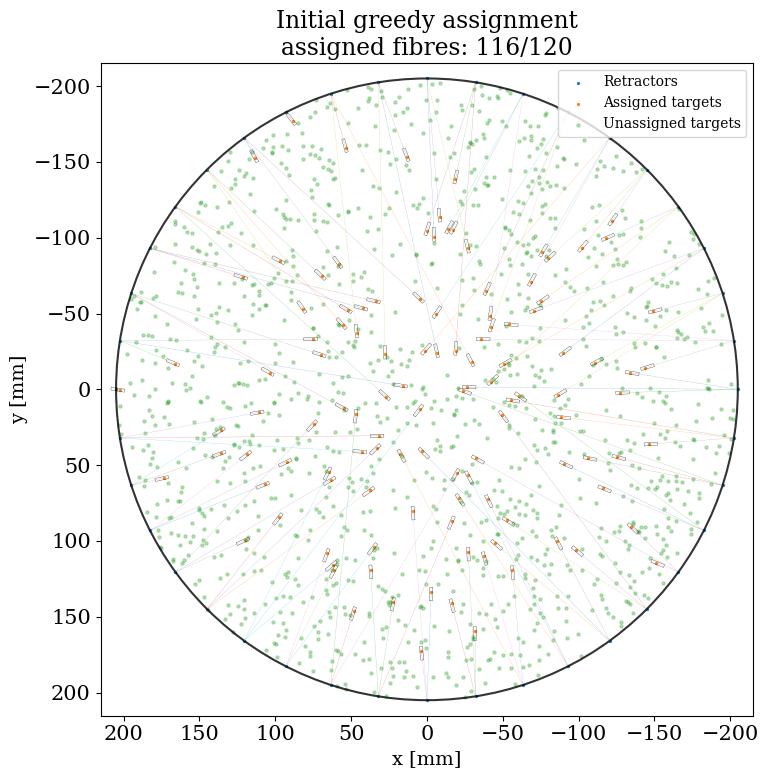

In [6]:
# =============================================================================
# SA SETUP
# =============================================================================
always_collide_np = np.array(always_collide_mat)
blocks_np = np.array(blocks_j)
potential_conflicts = build_potential_conflicts(n_targets, pairs, always_collide_np)
pc_sizes = np.array([len(x) for x in potential_conflicts], dtype=np.int32)
print(f"Average potential_conflicts per target: {pc_sizes.mean():.2f}")
print(f"Max potential_conflicts for any target: {pc_sizes.max()}")
px_np = np.array(px)
py_np = np.array(py)
retractor_x_np = np.array(retractor_x)
retractor_y_np = np.array(retractor_y)
r_id_np = np.array(r_id_for_fibre)  # fibre -> retractor id

# STATE ARRAYS
fibre_to_target = -np.ones(n_fibres, dtype=np.int32)
target_to_slot  = -np.ones(n_targets, dtype=np.int32)
target_to_fibre = -np.ones(n_targets, dtype=np.int32)

# Reverse mapping: fibre -> list of (target, slot)
fibre_to_possible = [[] for _ in range(n_fibres)]
for t in range(n_targets):
    for s in range(max_F):
        if target_fibre_mask[t, s]:
            f = int(target_fibre_ids[t, s])
            fibre_to_possible[f].append((t, s))

# Priorities (toy example)
_rng_pri = np.random.default_rng(99)
priorities = np.where(_rng_pri.random(n_targets) > 0.5, 10.0, 1.0)

# Straightness precompute
straightness = np.zeros((n_targets, max_F), dtype=np.float32)
_phi_max = np.deg2rad(14.0)
for t in range(n_targets):
    for s in range(max_F):
        if not target_fibre_mask[t, s]:
            continue
        f = int(target_fibre_ids[t, s])
        rid = int(r_id_np[f])
        vx = px_np[t] - retractor_x_np[rid]
        vy = py_np[t] - retractor_y_np[rid]
        rx, ry = -retractor_x_np[rid], -retractor_y_np[rid]
        cos_a = (vx*rx + vy*ry) / (np.hypot(vx, vy) * np.hypot(rx, ry) + 1e-12)
        straightness[t, s] = np.arccos(np.clip(cos_a, -1, 1)) / _phi_max

# Collision lookup
def collides(ti, si, tj, sj):
    if ti == tj:
        return False

    if always_collide_np[ti, tj]:
        return True

    if ti < tj:
        k = pair_index_np[ti, tj]
        if k == -1:
            return False
        return bool(blocks_np[k, si, sj])
    else:
        k = pair_index_np[tj, ti]
        if k == -1:
            return False
        return bool(blocks_np[k, sj, si])

def placement_valid(ti, si):
    pc = potential_conflicts[ti]
    if pc.size == 0:
        return True

    assigned_mask = (target_to_fibre[pc] != -1)
    if not np.any(assigned_mask):
        return True

    tj = pc[assigned_mask]
    sj = target_to_slot[tj]

    return not np.any(collides_many(ti, si, tj, sj))


def placement_valid_excluding(ti, si, exclude):
    pc = potential_conflicts[ti]
    if pc.size == 0:
        return True

    assigned_mask = (target_to_fibre[pc] != -1)
    if not np.any(assigned_mask):
        return True

    tj = pc[assigned_mask]

    if exclude:
        ex = np.fromiter(exclude, dtype=np.int32, count=len(exclude))
        tj = tj[~np.isin(tj, ex)]
        if tj.size == 0:
            return True

    sj = target_to_slot[tj]

    return not np.any(collides_many(ti, si, tj, sj))

def find_slot(fibre_id, target_id):
    return int(slot_lookup[fibre_id, target_id])

# Assign/unassign
def assign(f, t, s):
    fibre_to_target[f] = t
    target_to_slot[t] = s
    target_to_fibre[t] = f

def unassign_fibre(f):
    t = fibre_to_target[f]
    if t == -1:
        return -1, -1
    s = target_to_slot[t]
    fibre_to_target[f] = -1
    target_to_slot[t] = -1
    target_to_fibre[t] = -1
    return int(t), int(s)

def unassign_target(t):
    f = target_to_fibre[t]
    if f == -1:
        return -1, -1
    s = target_to_slot[t]
    fibre_to_target[f] = -1
    target_to_slot[t] = -1
    target_to_fibre[t] = -1
    return int(f), int(s)

# Energy
UNASSIGNED_PENALTY = 2.0

def energy_single(t, s):
    return (1.0 + straightness[t, s]) / priorities[t]

def energy_total():
    E = 0.0
    for f in range(n_fibres):
        t = fibre_to_target[f]
        if t == -1:
            E += UNASSIGNED_PENALTY
        else:
            E += energy_single(int(t), int(target_to_slot[t]))
    return float(E)

# Init
def init_assignment(seed=42):
    rng = np.random.default_rng(seed)
    order = rng.permutation(n_fibres)
    placed = 0
    for f in order:
        f = int(f)
        candidate_placements = list(fibre_to_possible[f])
        rng.shuffle(candidate_placements)
        for (t, s) in candidate_placements:
            t = int(t); s = int(s)
            if target_to_fibre[t] != -1:
                continue
            if placement_valid(t, s):
                assign(f, t, s)
                placed += 1
                break
    print(f"Initial assignment: {placed} out of {n_fibres} fibres placed")
    return placed

def reset_state():
    fibre_to_target[:] = -1
    target_to_slot[:]  = -1
    target_to_fibre[:] = -1

def accept(dE, T, rng):
    if dE <= 0:
        return True
    return rng.random() < np.exp(-1000.0 * dE / T)

# =============================================================================
# PLOTTING / DIAGNOSTICS
# =============================================================================
def snapshot_state():
    return {
        "fibre_to_target": fibre_to_target.copy(),
        "target_to_slot":  target_to_slot.copy(),
        "target_to_fibre": target_to_fibre.copy(),
    }

def plot_assignment(snapshot, filename, title="Assignment"):
    f2t = snapshot["fibre_to_target"]
    t2s = snapshot["target_to_slot"]

    assigned_targets = np.where(t2s >= 0)[0]
    unassigned_targets = np.where(t2s < 0)[0]

    fig, ax = plt.subplots(figsize=(8, 8))

    # Retractors
    ax.scatter(
        retractor_x_np,
        retractor_y_np,
        s=2,
        alpha=0.9,
        label="Retractors"
    )

    # Assigned targets
    ax.scatter(
        px_np[assigned_targets],
        py_np[assigned_targets],
        s=2,
        alpha=0.9,
        label="Assigned targets"
    )

    # Unassigned targets
    ax.scatter(
        px_np[unassigned_targets],
        py_np[unassigned_targets],
        s=5,
        alpha=0.3,
        label="Unassigned targets"
    )

    # Fibre paths and button footprints
    for t in assigned_targets:
        s = int(t2s[t])

        verts = np.array(target_vertices_j[t, s])
        start = np.array(target_fibre_start_j[t, s])
        end   = start + np.array(target_fibre_dir_j[t, s])

        # fibre path
        ax.plot(
            [start[0], end[0]],
            [start[1], end[1]],
            linewidth=0.2,
            alpha=0.5
        )

        # button footprint
        ax.add_patch(
            Polygon(
                verts,
                closed=True,
                fill=False,
                linewidth=0.2
            )
        )

    circ = plt.Circle((0, 0), r, fill=False, linewidth=1.5, alpha=0.8)
    ax.add_patch(circ)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(1.05 * r, -1.05 * r)
    ax.set_ylim(1.05 * r, -1.05 * r)
    ax.set_xlabel("x [mm]")
    ax.set_ylabel("y [mm]")
    ax.set_title(f"{title}\nassigned fibres: {len(assigned_targets)}/{n_fibres}")
    ax.legend(loc="upper right", fontsize=10)
    fig.tight_layout()
    fig.savefig(filename, dpi=200)
    plt.show(fig)
    plt.close(fig)

# =============================================================================
# RUN + SAVE FIGURES
# =============================================================================
reset_state()
init_assignment(seed=42)
snap_init = snapshot_state()
print(f"Initial energy: {energy_total():.2f}\n")

# Main configuration plots
plot_assignment(snap_init, os.path.join(PLOT_DIR, "assignment_initial.pdf"), title="Initial greedy assignment")


## Having a go at nested sampling!

In [7]:
# Particle representation: a list of length N_fibres containing target IDs, with -1 for unused fibres
fibre_to_target # has shape (N_fibres)

array([  -1,   -1, 1293,  844,  588,  520, 1069,  100,  262, 1082,  879,
       1035,  395,  235,  143, 1106, 1345,  215,  797,  423, 1327,  398,
        666, 1162, 1305,  496,   53, 1359,  633,  840, 1281, 1241,  761,
       1381,  893,  970,   84, 1181,  261,  334,  727,  289, 1393,  302,
        937, 1052,  248,  848,  384, 1014,  858,  669,  214,  822,  735,
       1203, 1255,  987,  203, 1157,  161,  487,    3, 1208, 1215, 1027,
       1315,  896, 1391,  474, 1166,  738, 1250,  146, 1314,  911, 1216,
       1088,  553,  836,  680, 1159,  159,  754,  557, 1238, 1137,  731,
        333,  533,  574, 1200,  925,  673, 1021, 1344,  792,   65,   20,
       1256,   -1,   -1,  710, 1115,  634,  263, 1195,  606,  311, 1095,
       1094,  369, 1198,  428,  656,  124,  315,  779,  623,  600],
      dtype=int32)

In [8]:
# GET PREVIOUS STATE COMONENTS FROM SINGLE 'PARTICLE' POSITION ARRAY

def state_from_position(position):
    """
    position: (n_fibres,) int array with entries = target_ID or -1 (unassigned)
    which represents one candidate nested sampling particle
    returns:
        fibre_to_target: copy of position
        target_to_fibre: (n_targets,) int, -1 if unassigned
        target_to_slot:  (n_targets,) int, -1 if unassigned
        OR
        None:  if the input position is invalid (e.g. assigns a target to multiple fibres, or assigns a fibre to an unreachable target)
    """
    pos = np.asarray(position, dtype=np.int32)
    fibre_to_target = pos.copy()
    target_to_fibre = -np.ones(n_targets, dtype=np.int32)
    target_to_slot  = -np.ones(n_targets, dtype=np.int32)

    for f, t in enumerate(pos): # f is fibre index, t is target index or -1
        if t == -1: # unassigned, already the base case
            continue

        if target_to_fibre[t] != -1: # if t has already been assigned, this is an invalid state
            return None # None signifies that the input position is NOT ALLOWED

        s = int(slot_lookup[f, t])
        if s == -1: # if fibre cannot reach target, invalid state
            return None

        target_to_fibre[t] = f
        target_to_slot[t]  = s

    return fibre_to_target, target_to_fibre, target_to_slot

In [9]:
# Check, for a given particle position, whether there are any collisions

def is_valid_position(position):
    """Given a particle position, check whether the assignment is valid (no collisions)
    Output:  True if valid, False if invalid"""
    state = state_from_position(position)
    if state is None:
        return False # NOT VALID

    fibre_to_target, target_to_fibre, target_to_slot = state

    assigned_targets = np.where(target_to_fibre != -1)[0] # indices of assigned targets
    for ti in assigned_targets:
        si = target_to_slot[ti]
        # only check neighbours in sparse conflict graph
        for tj in potential_conflicts[ti]: # for targets that potentially conflict with ti
            if tj <= ti: # don't check twice
                continue
            if target_to_fibre[tj] == -1: # no collision if tj is unassigned
                continue
            sj = target_to_slot[tj]
            if collides(ti, si, tj, sj): # specific check
                return False
    return True

In [10]:
reset_state()
init_assignment(seed=42)
assert is_valid_position(fibre_to_target.copy())

Initial assignment: 116 out of 120 fibres placed


In [11]:
arr = np.array([0,1,2,2,3,4,0,3,9])
np.where(arr != 0)[0]

array([1, 2, 3, 4, 5, 7, 8])

In [12]:
# NS PRIOR AND LIKELIHOOD
def energy_total_from_position(position):
    state = state_from_position(position)
    if state is None:
        return np.inf # Invalid state: infinite energy

    fibre_to_target, target_to_fibre, target_to_slot = state
    E = 0 # initially
    for f in range(n_fibres):
        t = fibre_to_target[f]
        if t == -1:
            E += UNASSIGNED_PENALTY
        else:
            s = target_to_slot[t]
            E += energy_single(t, s)
    return E

def logprior_fn(position):
    return 0.0 if is_valid_position(position) else -jnp.inf

def loglikelihood_fn(position):
    E = energy_total_from_position(position)
    if not np.isfinite(E): # if energy is infinite, this is an invalid state
        return -jnp.inf
    return -E # loglikelihood is negative energy, so that lower energy states have higher likelihood

In [13]:
# Draw n_live points of initial configurations, like in greedy init!

def random_valid_position(seed):
    rng = np.random.default_rng(seed)

    position = -np.ones(n_fibres, dtype=np.int32)
    target_to_fibre = -np.ones(n_targets, dtype=np.int32)
    target_to_slot  = -np.ones(n_targets, dtype=np.int32)

    def local_placement_valid(ti, si):
        pc = potential_conflicts[ti]
        if pc.size == 0:
            return True # placement is valid if nothing collides with ti

        assigned_mask = (target_to_fibre[pc] != -1)
        if not np.any(assigned_mask):
            return True # placement is valid if no potentially colliding targets are assigned

        tj_arr = pc[assigned_mask] # targets that are assigned and potentially collide with ti
        sj_arr = target_to_slot[tj_arr]
        return not np.any(collides_many(ti, si, tj_arr, sj_arr)) 
        # Above checks if ti in si collides with any tj on sj (assigned potentially conflicting targets)
        # It returns True if there is a collision, so check whether there is at least one (np.any)
        # Placement if VALID if np.any(collides_many(...)) is False, i.e. not a single collision found
        # Placement if INVALID if np.any(collides_many(...)) is True, i.e. at least one collision found

    for f in rng.permutation(n_fibres): # visit fibres in random order
        candidates = list(fibre_to_possible[f]) # possible (target, slot) pairs for this fibre
        rng.shuffle(candidates) # shuffle to add randomness

        for t, s in candidates:
            t = int(t)
            s = int(s)
            if target_to_fibre[t] != -1: # if target already assigned, can't place here
                continue
            if local_placement_valid(t, s): # if placing fibre f on target t in slot s doesn't cause collisions
                position[f] = t
                target_to_fibre[t] = f
                target_to_slot[t] = s
                break # break after first valid placement found for this fibre

    return position # return final configuration

In [14]:
valid = []
assigned = []
energy_total = []

for seed in range(450):
    pos = random_valid_position(seed)
    valid.append(is_valid_position(pos))
    assigned.append(np.sum(pos != -1))
    energy_total.append(energy_total_from_position(pos))

In [15]:
np.sum(valid) # so all assignments are valid!

450

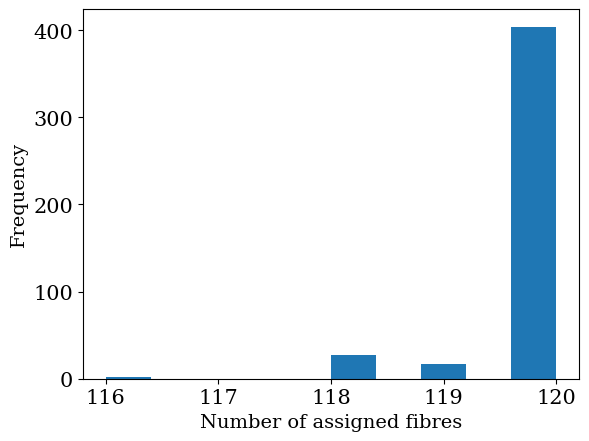

In [17]:
plt.hist(assigned)
plt.xlabel("Number of assigned fibres")
plt.ylabel("Frequency")
plt.show()

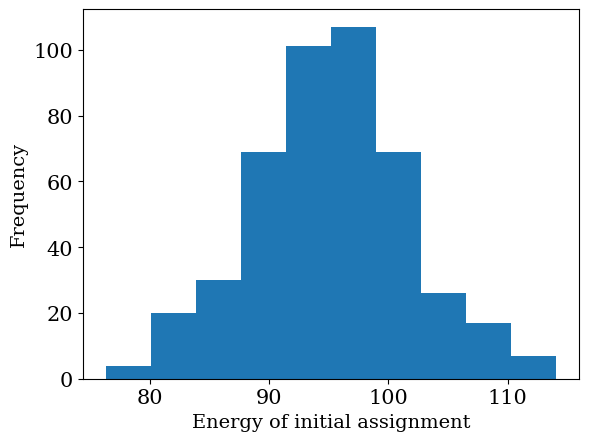

In [18]:
plt.hist(energy_total)
plt.xlabel("Energy of initial assignment")
plt.ylabel("Frequency")
plt.show()

In [19]:
# Take a valid configuration, try one random local move given 4 swap types
# QUESTION IS: starting from position, can I find one legal change to the state?
# If yes: return new state + True
# If no: return old state + False

def propose_swap_once(position, rng):
    """
    One random proposal using the same 4-path logic as SA (Miszalski, 2006),
    WITHOUT temperature & Metropolis acceptance.
    Returns (new_position, accepted_bool)
    """
    pos = np.asarray(position, dtype=np.int32).copy()
    state = state_from_position(pos)
    if state is None:
        return pos, False # current state is not valid, DO NOT ACCEPT

    fibre_to_target, target_to_fibre, target_to_slot = [x.copy() for x in state] # copy so that we do not affect global

    def assign_local(f, t, s):
        fibre_to_target[f] = t
        target_to_fibre[t] = f
        target_to_slot[t] = s

    def unassign_fibre_local(f):
        t = fibre_to_target[f]
        if t != -1:
            target_to_fibre[t] = -1
            target_to_slot[t] = -1
            fibre_to_target[f] = -1

    def unassign_target_local(t):
        f = target_to_fibre[t]
        if f != -1:
            fibre_to_target[f] = -1
            target_to_fibre[t] = -1
            target_to_slot[t] = -1

    def placement_valid_local(ti, si):
        pc = potential_conflicts[ti]
        if pc.size == 0:
            return True
        assigned_mask = (target_to_fibre[pc] != -1)
        if not np.any(assigned_mask):
            return True
        tj = pc[assigned_mask]
        sj = target_to_slot[tj]
        return not np.any(collides_many(ti, si, tj, sj))

    def placement_valid_excluding_local(ti, si, exclude):
        pc = potential_conflicts[ti]
        if pc.size == 0: # if no potential conflicts, all valid
            return True
        assigned_mask = (target_to_fibre[pc] != -1) # assigned where != -1
        if not np.any(assigned_mask): # if no assigned targets in potential conflicts, VALID
            return True
        tj = pc[assigned_mask]
        if exclude: # remove excluded targets from consideration
            ex = np.fromiter(exclude, dtype=np.int32, count=len(exclude))
            tj = tj[~np.isin(tj, ex)] # if tj is in ex, return tj[False], i.e. remove from tj; if tj is not in ex, return tj[True], i.e. keep in tj
            if tj.size == 0:
                return True
        sj = target_to_slot[tj]
        return not np.any(collides_many(ti, si, tj, sj))

    fibre_a = int(rng.integers(n_fibres)) # pick ranodm fibre as pivot for proposal
    possible = fibre_to_possible[fibre_a]
    if len(possible) == 0:
        return pos, False # fibre cannot reach any targts

    target_b, slot_ab = possible[rng.integers(len(possible))] # get another reachable target (b) for fibre_a, and the corresponding slot

    target_a = fibre_to_target[fibre_a] # current target for fibre_a
    fibre_b = target_to_fibre[target_b] # current fibre on target_b

    if target_a == target_b: # proposal is trivial
        return pos, False

    # type 1
    if target_a == -1 and fibre_b == -1:
        # If target a is unassigned, target b is unassigned
        # place fibre a on target b
        if placement_valid_local(target_b, slot_ab):
            assign_local(fibre_a, target_b, slot_ab)
            return fibre_to_target.copy(), True # return new position, success!

    # type 2
    elif target_a != -1 and fibre_b == -1:
        # If fibre_a is on target_a and target_b is unassigned
        # Remove fibre_a from target_a and place on target_b
        if placement_valid_excluding_local(target_b, slot_ab, exclude={target_a}):
            unassign_fibre_local(fibre_a)
            assign_local(fibre_a, target_b, slot_ab)
            return fibre_to_target.copy(), True # return new position, success!

    # type 3
    elif target_a == -1 and fibre_b != -1:
        # If target_a is unassigned and target_b is assigned
        # Replace fibre_b on target_b with fibre_a
        if placement_valid_excluding_local(target_b, slot_ab, exclude={target_b}):
            unassign_target_local(target_b)
            assign_local(fibre_a, target_b, slot_ab)
            return fibre_to_target.copy(), True # return new position, success!

    # type 4
    else:
        # If target_a is assigned and target_b is assigned, propose swap of fibres!
        slot_ba = int(slot_lookup[fibre_b, target_a])
        if slot_ba != -1:
            check1 = placement_valid_excluding_local(target_b, slot_ab, exclude={target_a, target_b})
            check2 = placement_valid_excluding_local(target_a, slot_ba, exclude={target_a, target_b})
            check3 = not collides(target_b, slot_ab, target_a, slot_ba)

            if check1 and check2 and check3:
                unassign_fibre_local(fibre_a)
                unassign_target_local(target_b)
                assign_local(fibre_a, target_b, slot_ab)
                assign_local(fibre_b, target_a, slot_ba)
                return fibre_to_target.copy(), True # return new position, success!

    return pos, False # return old position, failure!

# CREATE weave_nss.py